# Commodity forecasting | Target-aware feature research

**Feature gate: OPEN.** A feature-rich model has to beat credible simple controls. This study tests target-specific screening, economic routing, longer risk regimes, nonlinear interactions, and released-label history.

All comparisons use the corrected **535-date** development window. The original reservation contains a five-date permanent boundary buffer and **247 untouched final-test dates**. The original experiments are preserved; no leaderboard or trading-profit claims are made.

In [1]:
from pathlib import Path
import sys
if not Path("pyproject.toml").exists():
    sys.path.insert(0, str(Path.cwd().parent))
import json
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown
from scripts.notebook_support import project_root, checked_reports, checked_study, show_figure
root = project_root()
audit, research = checked_reports(root)
study = checked_study(root)
study_config = json.loads((root / "configs/feature_study.json").read_text())
config = json.loads((root / "configs/research.json").read_text())
display(Markdown(f"**Verified experiment:** `{study['lineage'][:16]}` · **Feature gate:** open"))

**Verified experiment:** `a904250065ff1ebb` · **Feature gate:** open

## Correct the benchmark and the time boundary

The first shared-screen Ridge experiment omitted a strong control: each target's historical training mean. We now include frozen training means and expanding means of labels that have actually been released.

A five-date terminal embargo removes development targets whose outcomes reach into the reserved interval. The initial models are rescored on these same 535 dates without refitting. Their old 540-date scores are historical records, not current comparisons. Because those overlapping outcomes were already inspected, origins 1709–1713 remain a permanent buffer; only origins 1714–1960 enter the eventual final test.

In [2]:
comparison = pd.DataFrame(study["comparison"])
legacy = pd.DataFrame(study["initial_variants_rescored_on_common_dates"])
controls = comparison.loc[comparison.variant.isin(["historical_mean", "released_mean"]), ["variant", "official_metric", "fold_metrics"]]
display(controls.round(4))
display(legacy[["variant", "official_metric"]].sort_values("official_metric", ascending=False).round(4))
display(Markdown(f"**Same-window comparison:** {study['validation_dates']} validation dates; {study['terminal_embargo_dates']}-date terminal embargo; all 30 original fold experiments preserved."))

,variant,official_metric,fold_metrics
0,historical_mean,0.2177,"[0.1625498054219968, 0.1824882692897385, 0.296..."
4,released_mean,0.1377,"[0.04828282242250848, 0.11071876286325584, 0.2..."


,variant,official_metric
0,add_ohlc,0.1022
1,add_pairs,0.0751
2,reference,0.0671
3,add_missingness,0.0671
4,add_reversion,0.0638
5,add_liquidity,0.0576
6,all_families,0.0497
8,add_cross_market,0.0264
7,add_volatility,0.0245
9,add_momentum,-0.0610


**Same-window comparison:** 535 validation dates; 5-date terminal embargo; all 30 original fold experiments preserved.

## Search broadly, route candidates to the prediction

The original nine families cover returns, momentum, volatility, reversion, liquidity, OHLC, missingness, market relationships, and target-pair spreads. Three added families test longer risk regimes, interactions, and released-label history.

Regimes include 126/252-date trends, risk ratios, tail shape, drawdown, autocorrelation, and trailing percentiles. Interactions combine momentum with volatility, relative returns, and reversion. Historical labels are shifted by exactly horizon + 1 before expanding, rolling, or exponential aggregation. Future-value mutation tests cover every new family.

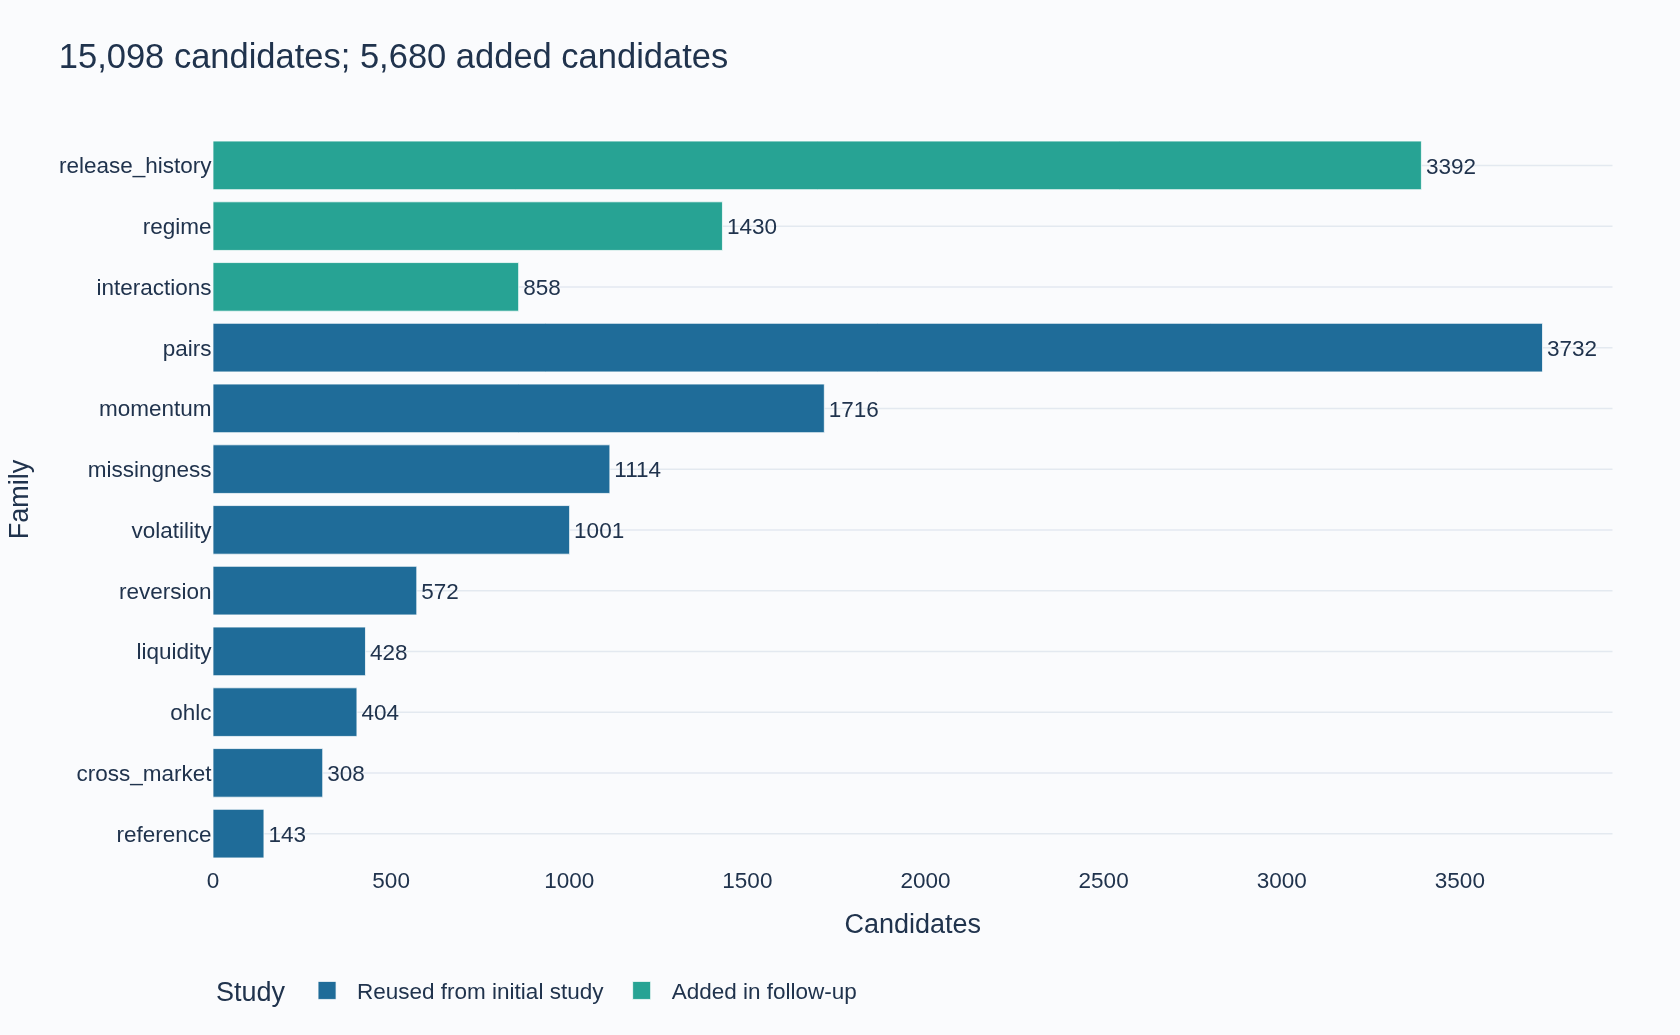

In [3]:
counts = pd.Series(study["family_counts"]).sort_values().rename_axis("Family").reset_index(name="Candidates")
counts["Study"] = np.where(counts.Family.isin(["regime", "interactions", "release_history"]), "Added in follow-up", "Reused from initial study")
fig = px.bar(counts, x="Candidates", y="Family", color="Study", orientation="h", text="Candidates",
             color_discrete_map={"Reused from initial study": "#1F6C99", "Added in follow-up": "#27A394"},
             title=f"{study['candidate_count']:,} candidates; {study['new_candidate_count']:,} added candidates")
fig.update_traces(textposition="outside")
fig.update_layout(legend={"orientation": "h", "y": -0.14})
show_figure(fig, root, "feature_families", 690)

## Hold model complexity fixed while changing representation

Each output can retain at most **24 features**, with training-only missingness, constant, duplicate, redundancy, and relevance checks. Stable screening requires the feature/target correlation to have the same sign in both training halves. Validation labels never enter the screener.

Aligned models see their own assets, exact pair, market context, and own released-label history. Structural models forecast asset returns first, then subtract components to preserve pair identities. Ridge alpha remains 100. A small fixed tree model checks nonlinear structure; automatic random early stopping is disabled.

The initial study used a shared 96-feature budget. Feature-attribution claims use matched controls inside this new 24-feature study.

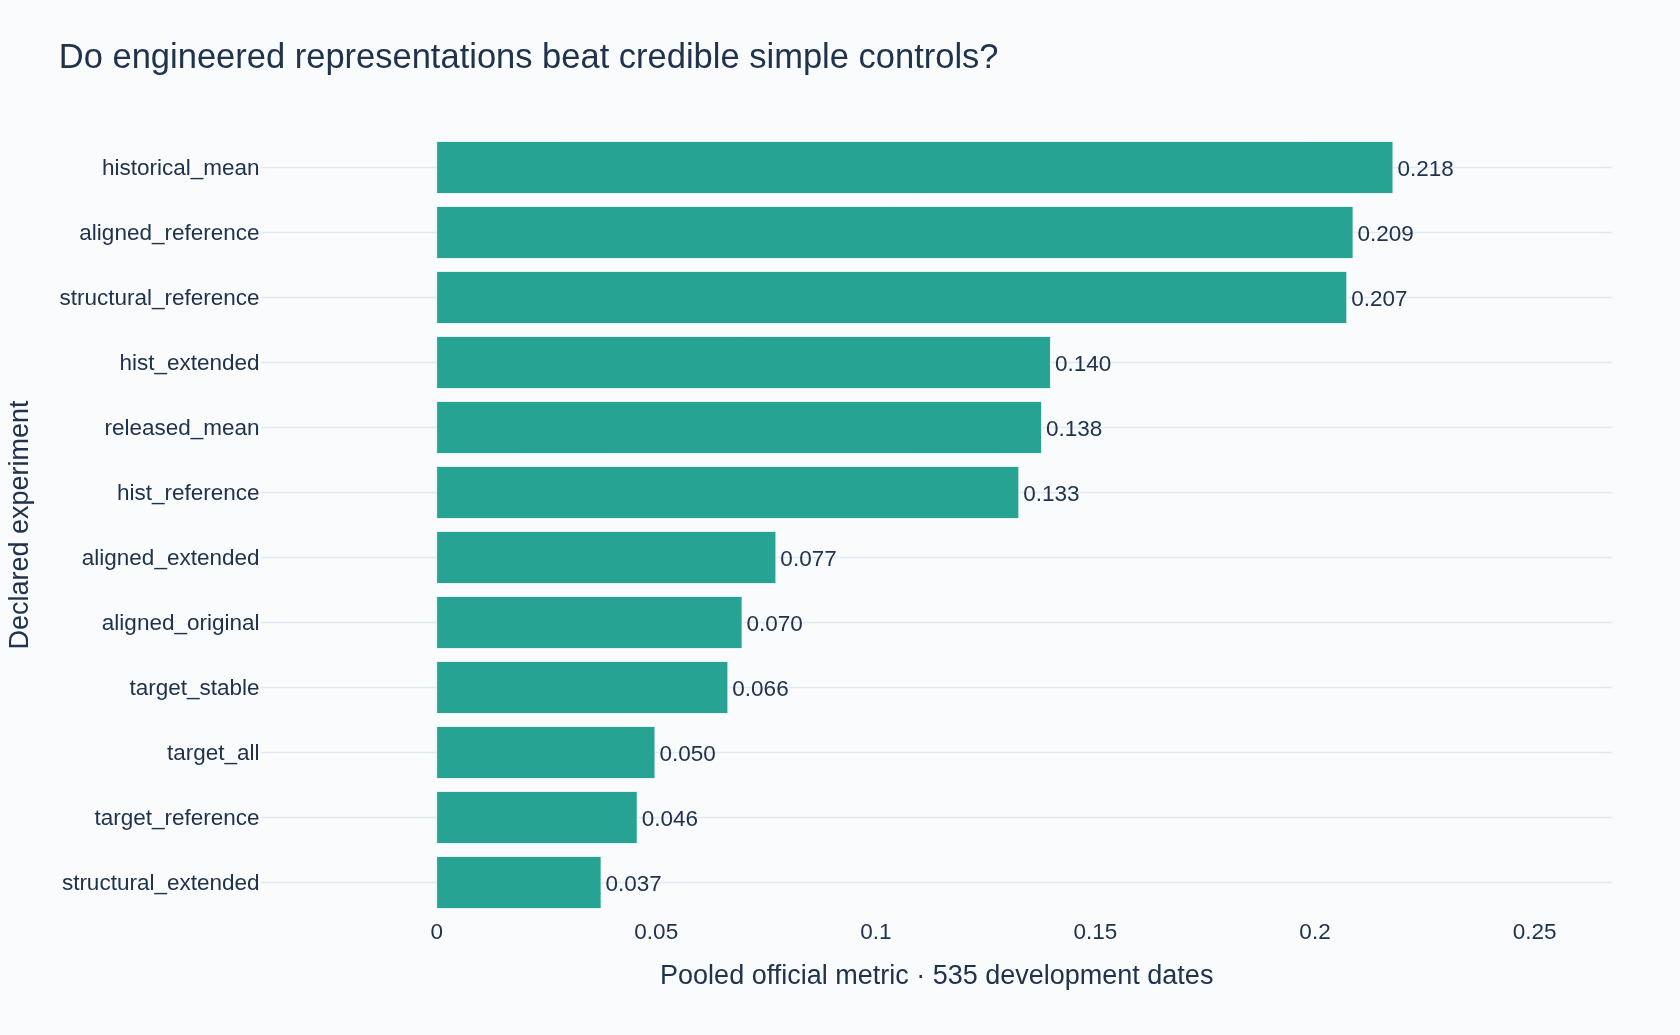

,variant,official_metric,mean_daily_rank_correlation,fold_metrics
0,historical_mean,0.2177,0.0458,"[0.1625498054219968, 0.1824882692897385, 0.296..."
1,aligned_reference,0.2087,0.0376,"[0.18846080346818364, 0.15181630184795522, 0.2..."
2,structural_reference,0.2072,0.0449,"[0.2046984676059178, 0.15098017890289422, 0.26..."
3,hist_extended,0.1398,0.0186,"[0.22812998923647995, 0.03725429947382911, 0.1..."
4,released_mean,0.1377,0.0314,"[0.04828282242250848, 0.11071876286325584, 0.2..."
5,hist_reference,0.1326,0.0168,"[0.06856313641909165, 0.08080476914422313, 0.2..."
12,aligned_extended,0.0772,0.0125,"[0.16464780319429506, -0.02305641120564604, 0...."
17,aligned_original,0.0695,0.0122,"[0.15130620130674452, -0.01551761340365714, 0...."
18,target_stable,0.0663,0.0109,"[0.12280555202259957, -0.011256661043576961, 0..."
19,target_all,0.0497,0.0089,"[0.14613819615240903, -0.12774538011787973, 0...."


In [4]:
main = comparison.loc[~comparison.variant.str.startswith("drop_")].sort_values("official_metric")
fig = px.bar(main, x="official_metric", y="variant", orientation="h", text_auto=".3f",
             title="Do engineered representations beat credible simple controls?")
fig.update_traces(marker_color="#27A394", textposition="outside")
fig.update_xaxes(range=[min(0, float(main.official_metric.min())) - 0.04, max(0, float(main.official_metric.max())) + 0.05])
fig.update_layout(xaxis_title="Pooled official metric · 535 development dates", yaxis_title="Declared experiment")
show_figure(fig, root, "ablation_scores", 690)
display(main[["variant", "official_metric", "mean_daily_rank_correlation", "fold_metrics"]].sort_values("official_metric", ascending=False).round(4))

## Matched comparisons separate feature value from other changes

The official metric is mean daily cross-sectional Spearman correlation divided by its population standard deviation. Feature value is a difference from a matched reference, not merely a high standalone score.

The chart shows simultaneous 95% bounds over the study's declared comparisons using 20-date blocks and 2,000 paired resamples within folds. Reports also include conditional intervals and 10-/40-date sensitivity. These bounds do not include fresh feature searches, refitting uncertainty, or all prior adaptive decisions.

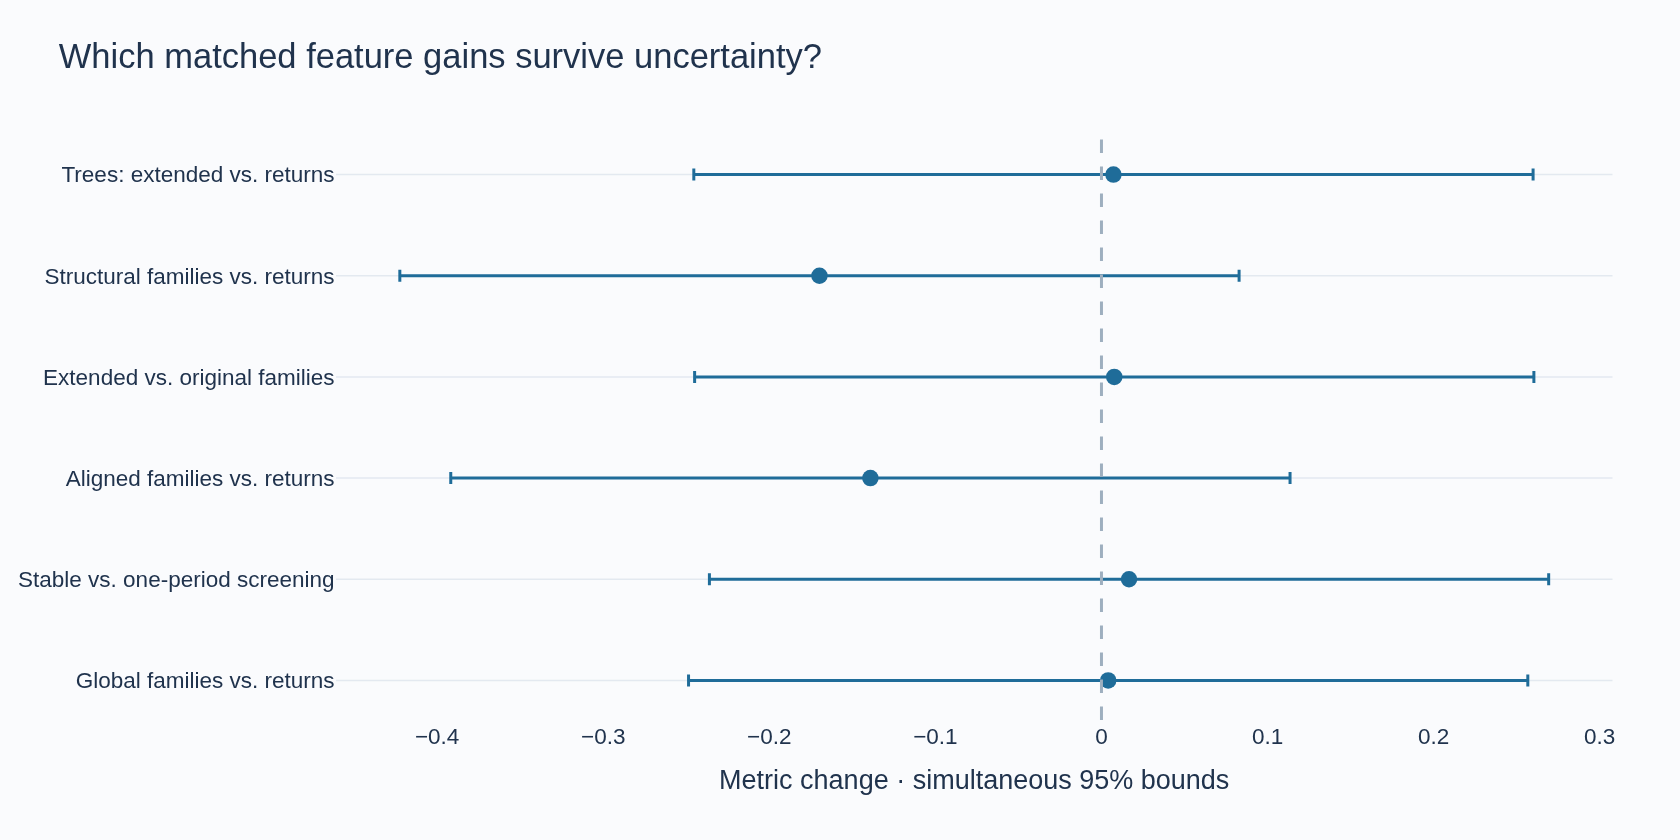

,Comparison,delta,conditional_95_interval,simultaneous_95_interval
62,Global families vs. returns,0.004041,"[-0.10862243826086511, 0.11755883184525671]","[-0.24862205260731507, 0.2567041962572768]"
63,Stable vs. one-period screening,0.016600,"[-0.05868773373109757, 0.09586012101072447]","[-0.23606331174358897, 0.2692629371210029]"
64,Aligned families vs. returns,-0.139124,"[-0.32070014281458104, 0.039068977013302]","[-0.3917869415139999, 0.11353930735059198]"
65,Extended vs. original families,0.007697,"[-0.0793185128991259, 0.09428367205118715]","[-0.2449658463006456, 0.26036040256394627]"
66,Structural families vs. returns,-0.169798,"[-0.35356182350299403, 0.02018627162469122]","[-0.4224609347394015, 0.08286531412519041]"
67,Trees: extended vs. returns,0.007213,"[-0.16226260547976623, 0.17329660440397873]","[-0.24545026298063968, 0.2598759858839522]"


In [5]:
bounds = pd.DataFrame(study["paired_intervals"])
labels = {
    ("target_all", "target_reference"): "Global families vs. returns",
    ("target_stable", "target_all"): "Stable vs. one-period screening",
    ("aligned_original", "aligned_reference"): "Aligned families vs. returns",
    ("aligned_extended", "aligned_original"): "Extended vs. original families",
    ("structural_extended", "structural_reference"): "Structural families vs. returns",
    ("hist_extended", "hist_reference"): "Trees: extended vs. returns",
}
matched = bounds.loc[(bounds.block_dates == 20) & bounds.apply(lambda r: (r.variant, r.reference) in labels, axis=1)].copy()
matched["Comparison"] = matched.apply(lambda r: labels[(r.variant, r.reference)], axis=1)
lo = matched.simultaneous_95_interval.map(lambda a: a[0])
hi = matched.simultaneous_95_interval.map(lambda a: a[1])
fig = go.Figure(go.Scatter(x=matched.delta, y=matched.Comparison, mode="markers", marker={"size": 11, "color": "#1F6C99"},
    error_x={"type": "data", "symmetric": False, "array": hi - matched.delta, "arrayminus": matched.delta - lo}))
fig.add_vline(x=0, line_dash="dash", line_color="#9EAFBF")
fig.update_layout(title="Which matched feature gains survive uncertainty?", xaxis_title="Metric change · simultaneous 95% bounds")
show_figure(fig, root, "ablation_uncertainty", 560)
display(matched[["Comparison", "delta", "conditional_95_interval", "simultaneous_95_interval"]])

## Conditional ablations: remove one family and refit

Every non-reference family is removed from the extended aligned representation while the same screening rule and estimator are refit. Positive deltas favor the full representation; negative deltas favor removal. An ablation measures the whole pipeline's dependence on a family, including replacement features selected after removal.

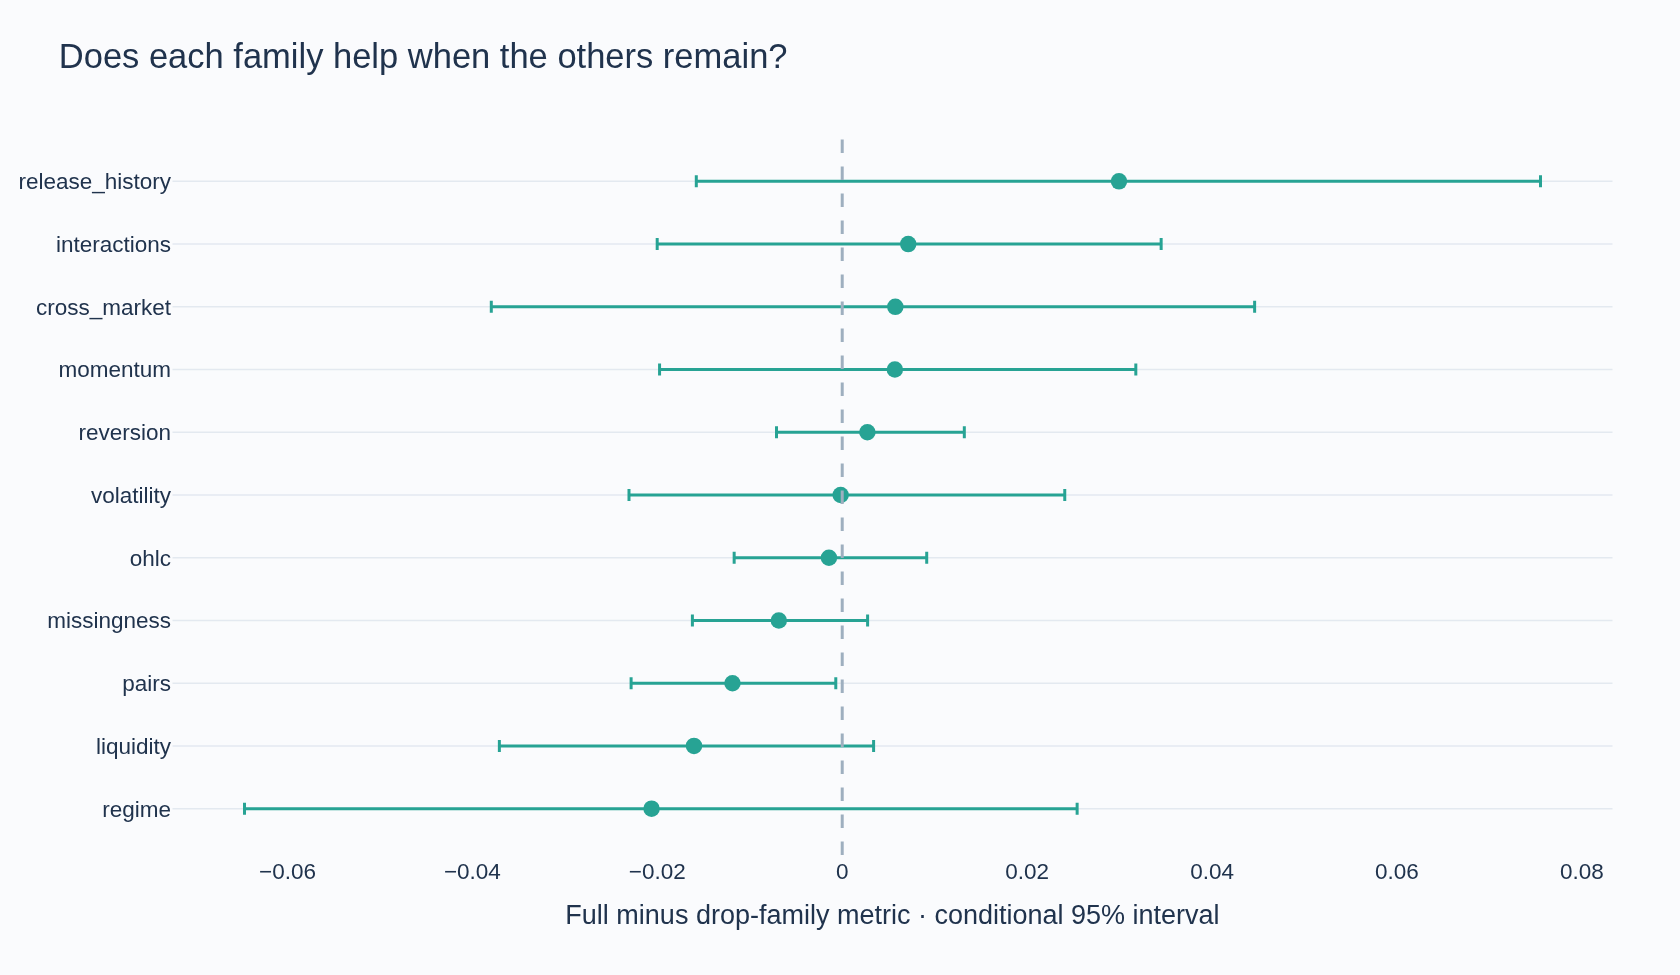

In [6]:
drops = bounds.loc[(bounds.block_dates == 20) & (bounds.variant == "aligned_extended") & bounds.reference.str.startswith("drop_")].sort_values("delta").copy()
drops["Family"] = drops.reference.str.removeprefix("drop_")
lo = drops.conditional_95_interval.map(lambda a: a[0])
hi = drops.conditional_95_interval.map(lambda a: a[1])
fig = go.Figure(go.Scatter(x=drops.delta, y=drops.Family, mode="markers", marker={"size": 11, "color": "#27A394"},
    error_x={"type": "data", "symmetric": False, "array": hi - drops.delta, "arrayminus": drops.delta - lo}))
fig.add_vline(x=0, line_dash="dash", line_color="#9EAFBF")
fig.update_layout(title="Does each family help when the others remain?", xaxis_title="Full minus drop-family metric · conditional 95% interval")
show_figure(fig, root, "conditional_ablations", 650)

## Stability across time and horizons

All variants use the same expanding folds. The final validation block is five dates shorter to enforce the holdout boundary. A pooled gain that reverses in a period needs additional evidence. Horizon diagnostics report eligible dates separately; they do not replace the primary metric across all observed targets.

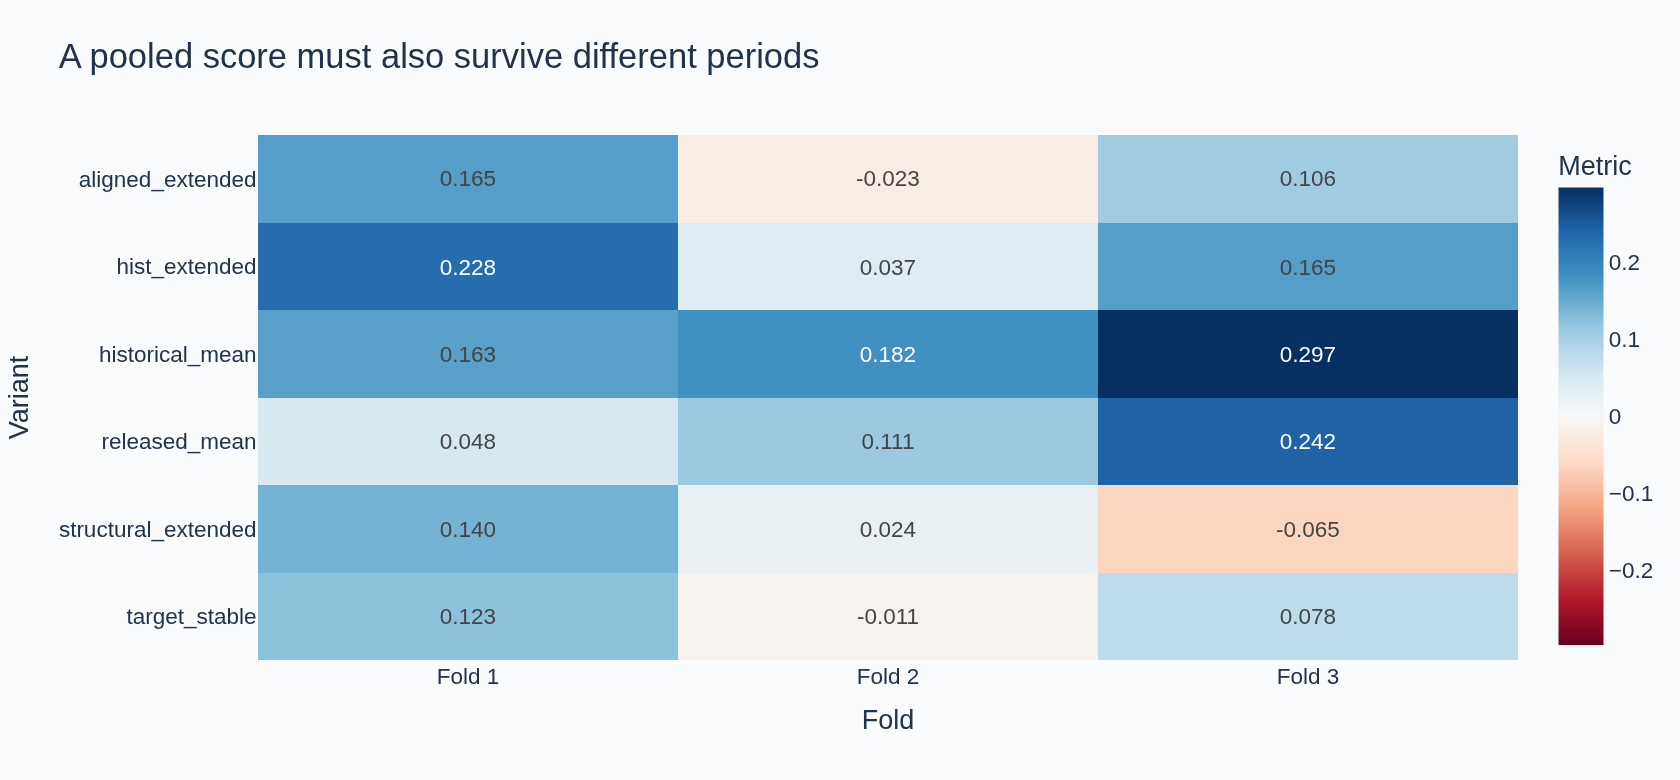

**Horizon diagnostics for the current point-estimate leader:** historical_mean

,Fold,Horizon,eligible_dates,excluded_dates,mean_daily_rank_correlation,official_metric
0,1,1,180,0,0.0328,0.1520
1,1,2,180,0,0.0223,0.0840
2,1,3,180,0,0.0365,0.1425
3,1,4,179,1,0.0135,0.0690
4,2,1,179,1,0.0332,0.1306
5,2,2,178,2,0.0366,0.1334
6,2,3,178,2,0.0470,0.1773
7,2,4,179,1,0.0395,0.1848
8,3,1,175,0,0.0677,0.2397
9,3,2,175,0,0.0940,0.2926


In [7]:
focus = ["historical_mean", "released_mean", "target_stable", "aligned_extended", "structural_extended", "hist_extended"]
rows = [{"Variant": r["variant"], "Fold": f"Fold {r['fold'] + 1}", "Metric": r["official_metric"]}
        for r in study["results"] if r["variant"] in focus]
matrix = pd.DataFrame(rows).pivot(index="Variant", columns="Fold", values="Metric")
fig = px.imshow(matrix, text_auto=".3f", color_continuous_scale="RdBu", color_continuous_midpoint=0, aspect="auto",
                title="A pooled score must also survive different periods", labels={"color": "Metric"})
show_figure(fig, root, "fold_stability", 520)
best_name = study["comparison"][0]["variant"]
horizon_rows = [{"Fold": r["fold"] + 1, "Horizon": h, **metrics} for r in study["results"] if r["variant"] == best_name for h, metrics in r["horizon_metrics"].items()]
display(Markdown(f"**Horizon diagnostics for the current point-estimate leader:** {best_name}"))
display(pd.DataFrame(horizon_rows).round(4))

## Model reliance and selection stability

Joint block permutation disrupts a family's date alignment while preserving within-date structure across targets. The model stays frozen. The chart averages changes in **fold-level** scores across five perturbations per fold. It is not a pooled official score or a causal importance estimate. Correlated groups can substitute for one another, and perturbations can leave the observed data distribution.

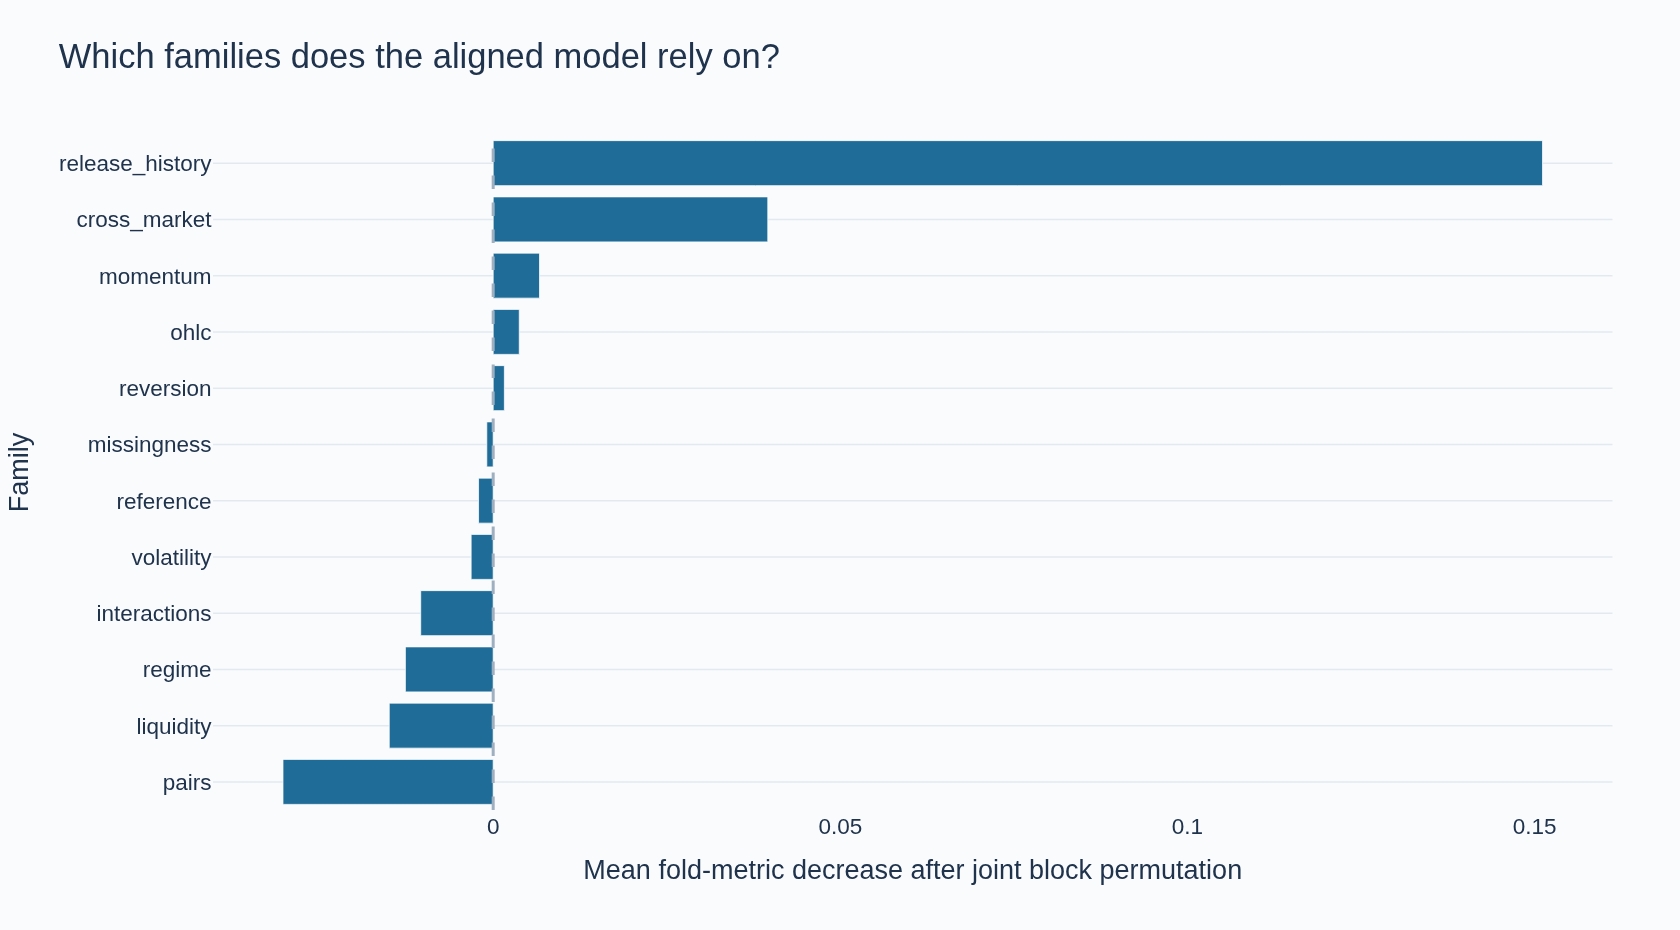

In [8]:
permutation_rows = []
for fold, groups in study["group_permutation"].items():
    for family, stats in groups.items():
        permutation_rows.extend({"Fold": fold, "Family": family, "Metric drop": value} for value in stats["metric_drop_repetitions"])
importance = pd.DataFrame(permutation_rows).groupby("Family")["Metric drop"].mean().sort_values().reset_index()
fig = px.bar(importance, x="Metric drop", y="Family", orientation="h", title="Which families does the aligned model rely on?")
fig.update_traces(marker_color="#1F6C99")
fig.add_vline(x=0, line_dash="dash", line_color="#9EAFBF")
fig.update_layout(xaxis_title="Mean fold-metric decrease after joint block permutation")
show_figure(fig, root, "group_permutation", 620)

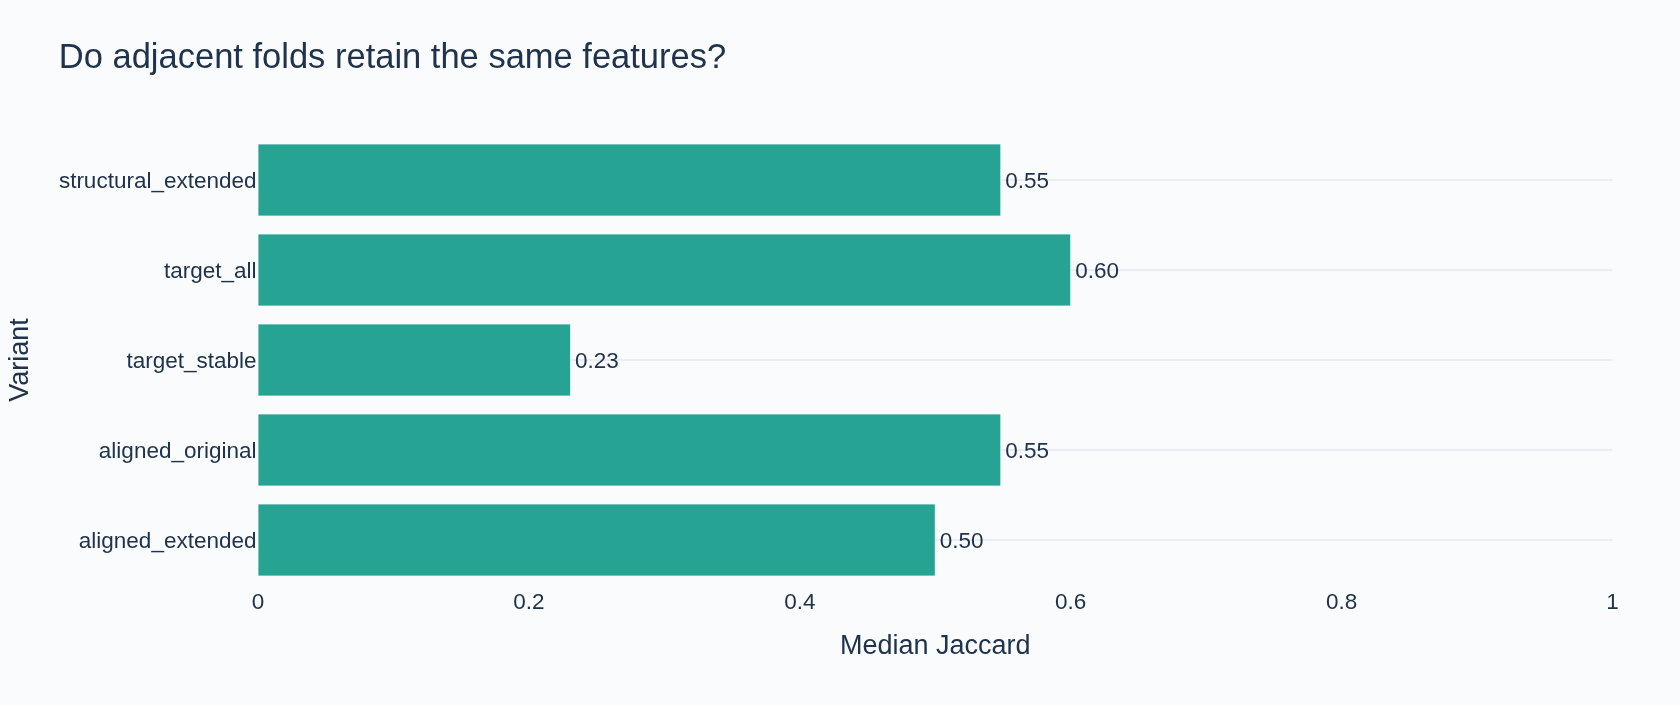

,Last-fold aligned screen
candidate_output_assignments,61598.0
retained_output_assignments,10176.0
rejected_output_assignments,51422.0
unique_retained_features,4241.0
retained_per_output_min,24.0
retained_per_output_median,24.0
retained_per_output_max,24.0


,Rejected assignments
unstable_sign_or_insufficient_history,27447
feature_budget,18687
duplicate,4906
constant,268
correlated,114


In [9]:
stability = pd.DataFrame([{"Variant": r["variant"], "Median Jaccard": r["selection_stability"]["median_jaccard"]}
    for r in study["comparison"] if r["variant"] in ["target_all", "target_stable", "aligned_original", "aligned_extended", "structural_extended"]])
fig = px.bar(stability, x="Median Jaccard", y="Variant", orientation="h", text_auto=".2f", title="Do adjacent folds retain the same features?")
fig.update_traces(marker_color="#27A394", textposition="outside")
fig.update_xaxes(range=[0, 1])
show_figure(fig, root, "selection_stability", 470)
last = next(r for r in study["results"] if r["variant"] == "aligned_extended" and r["fold"] == 2)
screening = last["screening"]
display(pd.Series({key: screening[key] for key in ["candidate_output_assignments", "retained_output_assignments", "rejected_output_assignments", "unique_retained_features", "retained_per_output_min", "retained_per_output_median", "retained_per_output_max"]}, name="Last-fold aligned screen").to_frame())
display(pd.Series(screening["rejection_reasons"], name="Rejected assignments").sort_values(ascending=False).to_frame())

Counts summed over target-specific screens are **feature/output assignments**. The same generated feature can enter several models. Unique candidates, unique retained features, and assignments are different quantities. A budget rejection does not prove absence of predictive signal.

In [10]:
best = study["comparison"][0]
mean_control = next(r for r in study["comparison"] if r["variant"] == "historical_mean")
display(Markdown(f"**Observed leader:** {best['variant']} at **{best['official_metric']:.4f}**. Frozen training means score **{mean_control['official_metric']:.4f}** on the same dates.\n\nCompleted **{study['experiments_completed']} fold/representation experiments** using **{study['candidate_count']:,} candidates**, while preserving all 30 initial experiments. Feature gate: **open**."))

**Observed leader:** historical_mean at **0.2177**. Frozen training means score **0.2177** on the same dates.

Completed **69 fold/representation experiments** using **15,098 candidates**, while preserving all 30 initial experiments. Feature gate: **open**.

## What the completed study says

Frozen training means lead at **0.2177**; aligned return-only Ridge is close at **0.2087**. Its difference from the mean control is **−0.0091**, with a conditional 95% interval of **[−0.0580, +0.0366]**. This is evidence to keep a strong prior benchmark in every future experiment.

The three added families improve aligned Ridge by only **+0.0077**, with interval **[−0.0793, +0.0943]**. Released-label history has the largest positive conditional ablation estimate (**+0.0299**), but its interval includes zero. Pair removal helps under a conditional interval, but does not survive simultaneous comparison bounds. No positive matched feature gain is established by the simultaneous bounds.

Richer aligned models reverse sign in the middle fold, and the extended structural model reverses in the last fold. These failures argue for investigating target priors, scale, and residual structure before broad tuning. More generated features are not evidence of more usable signal.

## Decision and remaining evidence

Keep the feature gate open. This study addresses credible mean controls, output-specific screening, economic routing, structural forecasts, longer risk regimes, released-label histories, conditional ablations, nonlinear controls, and block-size sensitivity. It does not establish diminishing returns for every plausible feature avenue.

Next decisions should follow the measured weaknesses: distinguish cross-sectional prior information from useful time-varying features, assess target/horizon normalization and robust residual representations, and test surviving interactions with nested temporal selection. External data require a defensible calendar mapping, source vintages, and appropriate rights; date IDs must not receive guessed calendar dates. Final optimization and reserved-holdout evaluation remain gated.

[Research protocol](../docs/research-protocol.md) · [Aggregate evidence](../reports/feature_study.json) · [Official metric](https://www.kaggle.com/code/metric/mitsui-co-commodity-prediction-metric).